In [14]:
import sys,os,re,argparse,glob
import pandas as pd
from scipy.io import loadmat
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

In [15]:
folders = [ "/home/tntiniak/Work/github/PhysiCell/mechanics_pushing_01_rep100/","/home/tntiniak/Work/github/PhysiCell/mechanics_pushing_001_rep100/","/home/tntiniak/Work/github/PhysiCell/mechanics_pushing_01_standard/","/home/tntiniak/Work/github/benchmark_2cells_mechanics/PhysiCell-1.14.0/output_randy/"]

In [16]:
for output_folder in folders:
    OUTPUT_COLUMNS = ['id', 'x', 'y', 'z', 'radius', 'nuclear_radius', 'ms', 'mbx']
    TIME_INTERVAL = 0.1

    # Initialize DataFrame
    df_cell = pd.DataFrame(columns=['id', 'x', 'y', 'z', 'radius', 'nuclear_radius', 'ms', 'mbx'])

    # Process each file
    files = sorted(Path(output_folder).glob('*output*_cells.mat'))
    df_list = []  # To accumulate DataFrames

    for i, file in enumerate(files):
        try:
            # Load .mat file and extract necessary data
            mat = loadmat(file)
            mat_data = mat['cells'][[0, 1, 2, 3, 37, 38, 53, 54]]
            # Create DataFrame from the .mat data
            df_mat = pd.DataFrame(mat_data.transpose(), columns=OUTPUT_COLUMNS)
            
            # Add time step column
            df_mat['dt'] = round(i * TIME_INTERVAL, 1)
            
            # Append to the list
            df_list.append(df_mat)
        
        except Exception as e:
            print(f"Error loading file {file}: {e}")

    df_cell = pd.concat(df_list, ignore_index=True)

    df_cell = df_cell.sort_values(by=['dt']).reset_index(drop=True)

    # Save to CSV
    output_csv = f"{output_folder}/cells_position_time.csv"
    df_cell.to_csv(output_csv, index=False)


In [17]:
output_folder

'/home/tntiniak/Work/github/benchmark_2cells_mechanics/PhysiCell-1.14.0/output_randy/'

In [18]:
df_cell

,id,x,y,z,radius,nuclear_radius,ms,mbx,dt
0,0.0,-15.000000,0.0,0.0,5.000004,3.14257,10.0,1.0,0.0
1,1.0,10.000000,0.0,0.0,5.000004,3.14257,10.0,-1.0,0.0
2,0.0,-13.500000,0.0,0.0,5.000004,3.14257,10.0,1.0,0.1
3,1.0,8.500000,0.0,0.0,5.000004,3.14257,10.0,-1.0,0.1
4,0.0,-12.500000,0.0,0.0,5.000004,3.14257,10.0,1.0,0.2
...,...,...,...,...,...,...,...,...,...
197,1.0,2.149975,0.0,0.0,5.000004,3.14257,0.0,-1.0,9.8
198,0.0,-7.152226,0.0,0.0,5.000004,3.14257,0.0,1.0,9.9
199,1.0,2.152226,0.0,0.0,5.000004,3.14257,0.0,-1.0,9.9
200,0.0,-7.154422,0.0,0.0,5.000004,3.14257,0.0,1.0,10.0


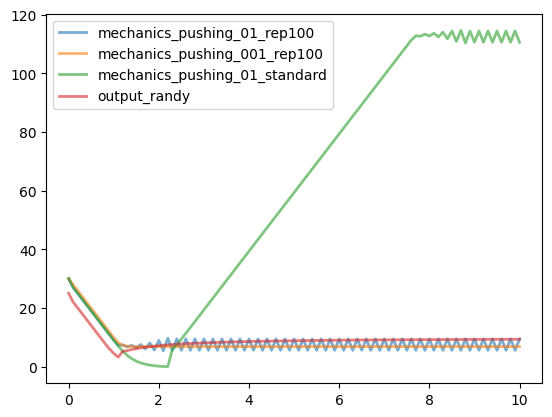

In [19]:
dataframes = {}
line_styles = ['-', '--', '-.', ':']  
colors = plt.cm.viridis(range(len(folders)))  

# Process each directory
for i, dir_path in enumerate(folders):  
    file_path = os.path.join(dir_path, "cells_position_time.csv")
    
    # key=os.path.basename(os.path.normpath(dir_path))
    key =  os.path.basename(os.path.normpath(dir_path))
    # Read the CSV file and process it
    df = pd.read_csv(file_path).sort_values(by=['dt']).reset_index(drop=True)
    pc_dist_dt =  abs(df[df['id']==0]['x'].reset_index() - df[df['id']==1]['x'].reset_index())
    pc_dist_dt["dt"] = df['dt'].unique()
    pc_dist_dt
    pc_dist_dt.rename({"x":"dx"},inplace=True,axis=1)
    pc_dist_dt.drop("index",axis=1,inplace=True)    
    dataframes[key] = pc_dist_dt
    
    # Plot the data
    plt.plot(
    pc_dist_dt['dt'], 
    pc_dist_dt['dx'], 
    label=key, 
    alpha=0.6,  # Transparency for better visibility
    linewidth=2  # Thicker lines for clarity
)
    plt.legend()
